# Lecture 7 - Solving Ax = 0: Pivot Variables and Special Solutions
Instructor: Gilbert Strang

In this lecture we study the homogeneous system

Ax = 0

This equation asks an important question:

Which vectors **x** are sent to the **zero vector** by the matrix **A**?

All such vectors form a set called the **null space of A**.

The goal of this lecture is to understand how the null space can be computed using elimination.
During the process we will discover several key ideas:

- pivot variables
- free variables
- special solutions
- reduced row echelon form (RREF)

The example matrix used throughout the lecture is

A =
[[1, 2, 2, 2],
 [2, 4, 6, 8],
 [3, 6, 8, 10]]

Before performing elimination, we can already notice two dependencies:

Column dependency
Column 2 = 2 × Column 1

Row dependency
Row 3 = Row 1 + Row 2

These dependencies tell us that the matrix cannot have full rank.
Elimination will reveal exactly how many independent directions remain.

Our objective is to find **all solutions of Ax = 0**, which will give the **null space of A**.

## Elimination and the Echelon Form

To understand the solutions of

Ax = 0

we begin with **Gaussian elimination**.

Elimination transforms the matrix step by step into a simpler form called the **echelon form**.
This process does **not change the solutions** of the system.

So instead of solving

Ax = 0

we will solve

Ux = 0

where **U** is the matrix produced by elimination.

This works because each elimination step corresponds to a combination of the original equations.
The system is rewritten, but its solutions remain the same.

During elimination we search for **pivot positions**.
A pivot is the first non–zero entry in a row after elimination.

Pivot positions will later tell us:

- which variables are **pivot variables**
- which variables are **free variables**

We will perform elimination and observe how the matrix structure changes.

In [8]:
from numpy import ndarray
from sympy import Matrix


def show_matrix(m: ndarray, title: str):
    print(title)
    display(Matrix(m))

In [9]:
import numpy as np

A = np.array([[1, 2, 2, 2],
              [2, 4, 6, 8],
              [3, 6, 8, 10]])
show_matrix(A, "Original matrix A")

Original matrix A


Matrix([
[1, 2, 2,  2],
[2, 4, 6,  8],
[3, 6, 8, 10]])

## Visualizing Changes in the Solution Space

The unknown vector

x = (x1, x2, x3, x4)

lives in R⁴.
Since R⁴ cannot be drawn directly, we visualize a **projection onto the first three coordinates**

(x1, x2, x3)

This projection still reveals the geometric structure of the solutions.

During the lecture we will plot vectors that represent directions in the solution space.
When elimination introduces constraints, the available directions shrink.

To help with this process we create a small visualization function that:

- plots vectors in 3D
- optionally shows the span generated by those vectors
- helps us observe how the space evolves as equations are appliedb

In [18]:

import matplotlib.pyplot as plt


def plot_vectores(M: np.ndarray, title: str):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    colors = ['red', 'green', 'blue', 'yellow', 'magenta', 'cyan']
    max_range = max(np.abs(M).max(), 1)

    for i in range(M.shape[1]):
        v = M[:, i]
        ax.quiver(0, 0, 0, v[0], v[1], v[2], color=colors[i % len(colors)])

    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    ax.set_zlim(-max_range, max_range)

    ax.set_box_aspect([1, 1, 1])

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

    ax.set_title(title)
    plt.show()

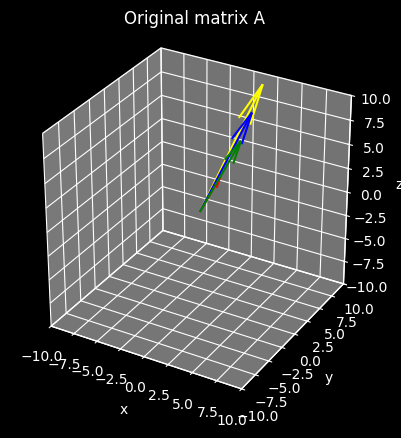

In [19]:
plot_vectores(A, title="Original matrix A")

## First Elimination Step

The first pivot appears in the first column.

The entry in position (1,1) is non–zero, so it can be used to eliminate the entries
below it in the same column.

The goal of this step is simple:

make the entries below the pivot equal to zero.

We do this by subtracting multiples of the first row from the rows below it.

Row operations:

- row2 = row2 − 2 × row1
- row3 = row3 − 3 × row1

These operations remove the first column entries in rows 2 and 3.

Important idea:

Row operations **do not change the solution set of Ax = 0**.
They only rewrite the system into a simpler form.

After performing these operations the matrix moves closer to its
**echelon structure**, where zeros appear below pivot positions.

In [10]:
U = A.copy()

U[1] = U[1] - 2 * U[0]
U[2] = U[2] - 3 * U[0]

show_matrix(U, "Matrix after first elimination step")

Matrix after first elimination step


Matrix([
[1, 2, 2, 2],
[0, 0, 2, 4],
[0, 0, 2, 4]])

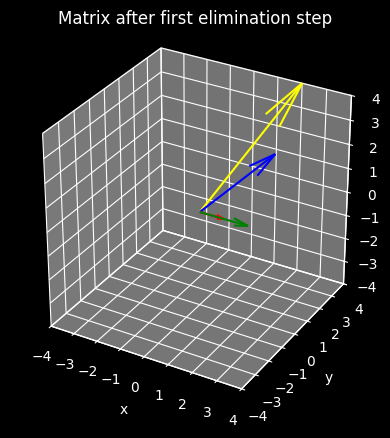

In [16]:
plot_vectores(U, title="Matrix after first elimination step")

## Second Elimination Step

After the first elimination, the first column already has zeros below its top entry.

Now we look at the next rows and continue the elimination process.

The goal of elimination is always the same:
create zeros **below the leading entries** so the matrix moves toward an **echelon form**.

In this step we compare the remaining rows and remove the repeated equation.

This reveals an important idea in linear algebra:

Sometimes an equation in the system is not new information.
It can be written as a combination of the previous equations.

When that happens, elimination produces a **row of zeros**.
This means the system contains redundant equations.

We now perform the next row operation to simplify the matrix further.

Matrix after second elimination step


Matrix([
[1, 2, 2, 2],
[0, 0, 2, 4],
[0, 0, 0, 0]])

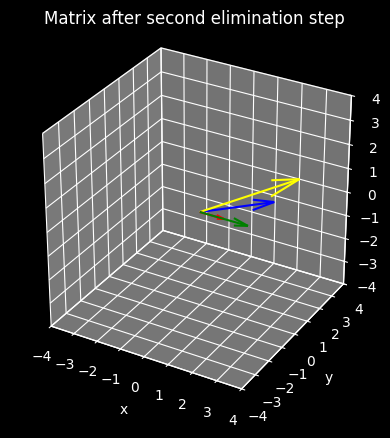

In [20]:
U[2] = U[2] - U[1]
show_matrix(U, title="Matrix after second elimination step")
plot_vectores(U, title="Matrix after second elimination step")

## Pivot Columns and Free Variables

After elimination the matrix is now in echelon form.

In echelon form we look for the **leading entries** in each non-zero row.
These leading entries are called **pivots**.

A pivot indicates that the corresponding variable is determined by the system.

The columns containing pivots are called **pivot columns**.

The remaining columns are called **free columns**, because their variables
are not fixed by the equations and can take arbitrary values.

From the echelon matrix we observe:

pivot columns → column 1 and column 3
free columns → column 2 and column 4

This means:

- x1 and x3 are **pivot variables**
- x2 and x4 are **free variables**

The number of pivots is called the **rank** of the matrix.

rank(A) = number of pivots

For this matrix there are two pivots.

So

rank(A) = 2

In [25]:
pivot_columns = []
for row in U:
    for col_i, col_v in enumerate(row):
        if col_v != 0:
            pivot_columns.append(col_i)
            break
print(pivot_columns)

[0, 2]


## The System Ux = 0

After elimination we solve

Ux = 0

because elimination does not change the solution set of the system.

The matrix U gives us a system of linear equations relating the variables
x1, x2, x3, x4.

Each non-zero row corresponds to one equation.

From these equations we will identify which variables are determined by
the system (pivot variables) and which variables can be chosen freely
(free variables).

The free variables will generate the **special solutions** that span
the null space of A.

In [27]:
variables = ['x1', 'x2', 'x3', 'x4']

for row in U:
    equations = []
    for col_i, col_v in enumerate(row):
        if col_v != 0:
            equations.append(f"{col_v}{variables[col_i]}")
    if equations:
        print(" + ".join(equations), end=" = 0\n")

1x1 + 2x2 + 2x3 + 2x4 = 0
2x3 + 4x4 = 0


## Pivot Variables and Free Variables

From the echelon system we obtained the equations

- x1 + 2x2 + 2x3 + 2x4 = 0
- 2x3 + 4x4 = 0

From the pivot columns we already know:

- pivot variables → x1 , x3
- free variables → x2 , x4

Free variables are not determined by the system.
They can take any value.

The pivot variables must adjust themselves so that the equations remain satisfied.

So the strategy is:

1. choose values for the free variables
2. compute the pivot variables from the equations

Each choice of free variables produces one solution of Ax = 0.

Among all solutions, we will construct special ones called **special solutions**.
These special solutions will form the building blocks of the null space.

## Expressing Pivot Variables

We now solve the equations for the pivot variables.

From the second equation:

- 2x3 + 4x4 = 0

which gives

- x3 = -2x4

Now substitute this into the first equation:

- x1 + 2x2 + 2(-2x4) + 2x4 = 0

which simplifies to

- x1 = -2x2 + 2x4

So the pivot variables depend on the free variables:

- x1 = -2x2 + 2x4
- x3 = -2x4

Now every solution of Ax = 0 is determined by choosing values
for the free variables x2 and x4.

In [29]:
# free variables case 1
x2 = 1
x4 = 0

x3 = -2 * x4
x1 = -2 * x2 + 2 * x4

v1 = np.array([x1, x2, x3, x4])

# free variables case 2
x2 = 0
x4 = 1

x3 = -2 * x4
x1 = -2 * x2 + 2 * x4

v2 = np.array([x1, x2, x3, x4])

print("First Case: ", v1)
print("Second Case: ", v2)

First Case:  [-2  1  0  0]
Second Case:  [ 2  0 -2  1]


## Special Solutions

By choosing values for the free variables we obtained two special solutions.

First special solution (set x2 = 1, x4 = 0)

[-2
  1
  0
  0]

Second special solution (set x2 = 0, x4 = 1)

[ 2
  0
 -2
  1]

These vectors satisfy

Ax = 0

Each one corresponds to activating **one free variable at a time**.

The number of special solutions equals the number of free variables.

## The Null Space of A

Every solution of Ax = 0 can now be written as a linear combination
of the special solutions.

x = c · [-2, 1, 0, 0] + d · [2, 0, -2, 1]

The set of all such combinations forms the **null space of A**.

Important observation:

- number of variables = n = 4
- rank(A) = 2

number of free variables = n − rank = 2

This matches the number of special solutions we found.

So the null space has **dimension 2**.

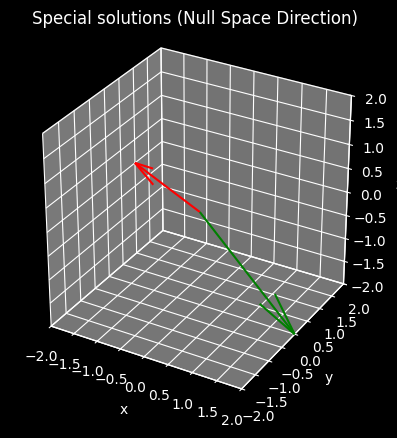

[[-2  2]
 [ 1  0]
 [ 0 -2]
 [ 0  1]]


In [38]:
plot_vectores(np.array([v1, v2]).T, title="Special solutions (Null Space Direction)")

## Visualizing the Null Space Directions

The two special solutions are

- v1 = [-2, 1, 0, 0]
- v2 = [2, 0, -2, 1]

These vectors form the **basis of the null space**.

Any solution of Ax = 0 can be written as

x = c v1 + d v2

for some scalars c and d.

Because there are two independent directions, the null space has
dimension 2.

Since the vectors live in R⁴, we cannot visualize them directly.

To build geometric intuition we project the vectors to their
first three coordinates.

The resulting plot shows two independent directions starting
from the origin.

The plane spanned by these directions represents the projection
of the null space.

## From Echelon Form to Reduced Form

The echelon matrix already reveals the pivot structure of the system.

But we can simplify it even further.

By continuing the row operations we can obtain a matrix where

- pivot entries are equal to 1
- all other entries in pivot columns are zero

This form is called the **reduced row echelon form**.

The reduced form makes the structure of the system completely clear.
It will allow us to express the solutions of Ax = 0 in a compact way.

In [39]:
R = U.copy()

R[0] = R[0] - R[1]
R[1] = R[1] / 2

show_matrix(R, "Reduced row echelon form (RREF)")

Reduced row echelon form (RREF)


Matrix([
[1, 2, 0, -2],
[0, 0, 1,  2],
[0, 0, 0,  0]])

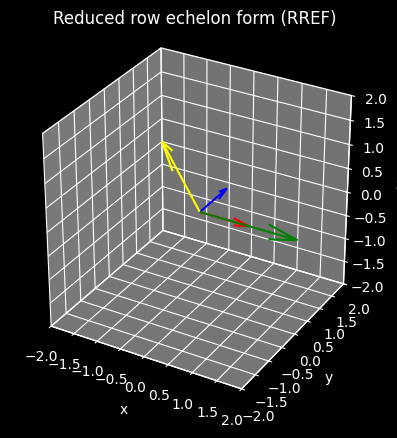

In [40]:
plot_vectores(R, title="Reduced row echelon form (RREF)")

## Structure of the Reduced System

After continuing the row operations, the matrix now has a very clear structure.

The pivot columns form an identity matrix inside the system.

This means the pivot variables appear in the simplest possible way:
each pivot variable is isolated in one equation.

The remaining columns correspond to the free variables.

So the matrix separates naturally into two parts:

pivot columns → identity structure
free columns → coefficients relating free variables to pivot variables

Symbolically this structure can be written as

R = [ [I,  F]
      [0,  0]]

where

- I is the identity matrix corresponding to the pivot variables
- F contains the coefficients that connect pivot variables to free variables

The bottom rows are zero rows because the system had redundant equations.

## The System Rx = 0

The reduced matrix represents a simpler system of equations.

From it we can read the relationships between pivot variables and free variables directly.

The pivot variables appear on the left side of the equations,
while the free variables appear on the right side.

This structure makes the null space extremely easy to describe.

In [47]:
free_cols = [i for  i in range(R.shape[1]) if i not in pivot_columns]
r = len(pivot_columns)

I_block = R[:r, pivot_columns]
F_block = R[:r, free_cols]

show_matrix(I_block, "Identity block")
show_matrix(F_block, "Coefficient block")

Identity block


Matrix([
[1, 0],
[0, 1]])

Coefficient block


Matrix([
[2, -2],
[0,  2]])

## Splitting the Variables

Let us separate the variables into two groups.

Pivot variables

x_pivot = [x1, x3]

Free variables

x_free = [x2, x4]

The reduced system can now be written in matrix form as

[[I], [F]] * [[x_pivot], [x_free ]] = 0

Multiplying the matrices gives

x_pivot + F x_free = 0

So the pivot variables must satisfy

x_pivot = -F x_free

In [53]:
N = np.zeros((4, 2))
N[pivot_columns, :] = -F_block
N[free_cols, :] = np.eye(2)
show_matrix(N, "Null space matrix")

Null space matrix


Matrix([
[-2.0,  2.0],
[ 1.0,  0.0],
[ 0.0, -2.0],
[ 0.0,  1.0]])

## The Null Space Matrix

Because

x_pivot = -F x_free

every solution of Ax = 0 can be written in the form

x = [ -F ]
    [  I ]  x_free

The matrix

N = [ -F
      I ]

contains the **special solutions as its columns**.

This matrix is called the **null space matrix**.

It satisfies

R N = 0

## The Transpose Matrix

Now we repeat the same elimination process for the transpose of A.

The transpose of a matrix swaps rows and columns.

If

A is an m × n matrix,

then

Aᵀ is an n × m matrix.

The transpose of our matrix becomes

Aᵀ

which contains the columns of A written as rows.

We will apply elimination again and observe how many pivots appear.

Transpose of A


Matrix([
[1, 2,  3],
[2, 4,  6],
[2, 6,  8],
[2, 8, 10]])

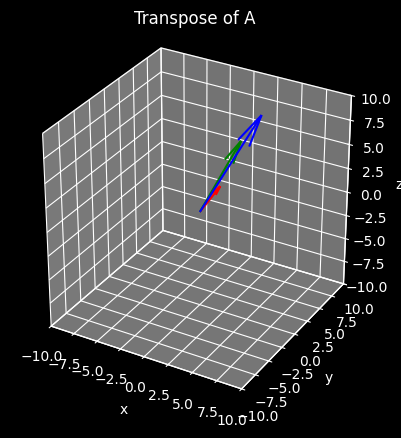

In [55]:
A_T = A.T
show_matrix(A_T, "Transpose of A")
plot_vectores(A_T, title="Transpose of A")

## Elimination on the Transpose

We now perform elimination on Aᵀ in the same way we did for A.

The goal is again to create zeros below pivot positions so the matrix
moves toward echelon form.

By doing this we will reveal the pivot columns of Aᵀ.

The interesting question is:

Will the number of pivots change after transposing the matrix?

After first elimination step


Matrix([
[1, 2, 3],
[0, 2, 2],
[0, 0, 0],
[0, 0, 0]])

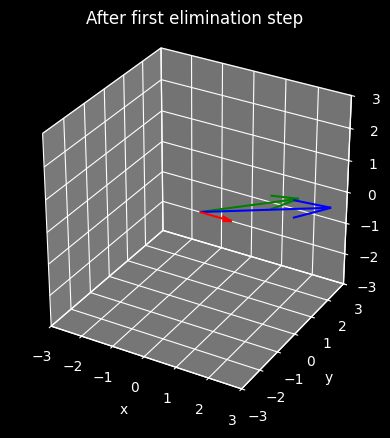

In [75]:
U_T = A_T.copy()

U_T[1] = U_T[1] - 2 * U_T[0]
U_T[2] = U_T[2] - 2 * U_T[0]
U_T[3] = U_T[3] - 2 * U_T[0]
U_T[[1, 2]] = U_T[[2, 1]]
U_T[3] = U_T[3] - 2 * U_T[1]

show_matrix(U_T, "After first elimination step")
plot_vectores(U_T, title="After first elimination step")

## Echelon Form of the Transpose

After performing elimination on the transpose matrix Aᵀ we obtain an echelon matrix.

Looking at this matrix we identify the pivot positions by finding the first
non-zero entry in each non-zero row.

These leading entries indicate the pivot columns.

The important observation is that the transpose matrix also has
two pivot positions.

So

rank(Aᵀ) = 2

But earlier we found

rank(A) = 2

This reveals an important property of matrices:

A matrix and its transpose always have the **same rank**.

In [76]:
pivot_cols_T = []

for row in U_T:
    for i, v in enumerate(row):
        if v != 0:
            pivot_cols_T.append(i)
            break

print(pivot_cols_T)

[0, 1]


## Solving Aᵀx = 0

We now solve the homogeneous system

Aᵀx = 0

Using the echelon matrix we obtain the equations

- x1 + 2x2 + 3x3 = 0
- 2x2 + 2x3 = 0

From the pivot structure we see that

- pivot variables → x1 , x2
- free variable → x3

So the solution will be determined by choosing the value of x3.

In [77]:
x3 = 1

x2 = -x3
x1 = -2*x2 - 3*x3

v = np.array([x1, x2, x3])

print(v)

[-1 -1  1]


## Null Space of Aᵀ

The null space of Aᵀ is generated by the vector

[-1, -1, 1]

Every solution of Aᵀx = 0 can be written as

x = c · [-1, -1, 1]

So the null space has dimension 1.

This matches the rank relationship

number of variables − rank = dimension of the null space

For Aᵀ

n = 3

rank = 2

so

dimension of null space = 1


## Reducing the Transpose Matrix

The echelon matrix can be simplified further.

By continuing the row operations we can make

- each pivot equal to 1
- all other entries in pivot columns equal to zero

This produces the reduced row echelon form.

This step reveals the relationships between pivot variables
and free variables in the simplest possible way.

Reduced row echelon form (RREF)


Matrix([
[1, 0, 1],
[0, 1, 1],
[0, 0, 0],
[0, 0, 0]])

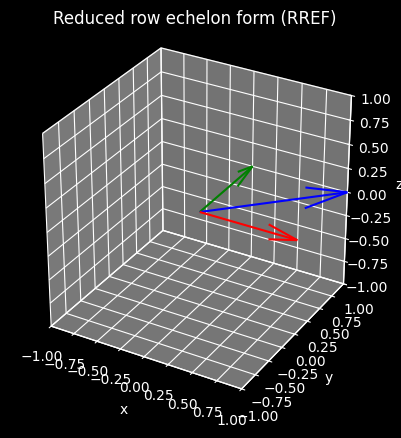

In [79]:
R_T = U_T.copy()

R_T[1] = R_T[1] / 2
R_T[0] = R_T[0] - 2 * R_T[1]

show_matrix(R_T, "Reduced row echelon form (RREF)")
plot_vectores(R_T, title="Reduced row echelon form (RREF)")

## Reading the Structure

The reduced matrix now clearly separates pivot and free variables.

The pivot columns form an identity matrix.

The remaining column corresponds to the free variable.

From the system we read

- x1 + x3 = 0
- x2 + x3 = 0

So

- x1 = -x3
- x2 = -x3

Choosing x3 = 1 produces the special solution

[-1, -1, 1]

which spans the null space of Aᵀ.

## Lecture Summary — Solving Ax = 0

In this lecture we studied how elimination reveals the structure of the solutions of a homogeneous system

Ax = 0

Starting from the matrix A, we applied Gaussian elimination to transform the system into an echelon form U.
This transformation does not change the solution set, so solving

Ax = 0

is equivalent to solving

Ux = 0.

From the echelon matrix we identified the **pivot columns** and **free columns**.

Pivot variables are determined by the equations.
Free variables can take arbitrary values.

For this matrix we found

rank(A) = 2

which means two pivot variables and two free variables.

By assigning values to the free variables we constructed **special solutions**.
These vectors form a basis for the **null space of A**.

Every solution of the system can therefore be written as a linear combination of the special solutions.

This reveals an important principle of linear algebra:

dimension of null space = number of free variables = n − rank(A)

We then repeated the elimination process for the transpose matrix Aᵀ.
Although the matrix shape changed, the number of pivots remained the same.

This showed an important property:

rank(A) = rank(Aᵀ)

The key ideas from this lecture are:

- elimination reveals the structure of a system
- pivot variables and free variables determine the solution set
- special solutions form the basis of the null space
- the dimension of the null space equals n − rank
- a matrix and its transpose always have the same rank

These ideas will soon connect to a deeper structure in linear algebra:
the **four fundamental subspaces of a matrix**.